# Exponential Smoothing: Forecasts That Forget

**DCS 404 · Data Science and Machine Learning**

---

Module 10 ended on an unresolved note. We scored four baseline forecasts on the final two years of Air
Passengers, and **seasonal naive** won on every metric — MAE of 71.25 thousand passengers, MAPE of 15.5%.
Then we looked at its residuals and found something the score alone had hidden: the mean residual was
$+71.25$, *exactly equal to the MAE*, which can only happen when essentially every error points the same
way. Seasonal naive does not make random mistakes. It **systematically under-forecasts**, every month,
by roughly one year's worth of growth, because replaying last July tells you nothing about the fact that
the airline is bigger this year than it was last year.

The diagnosis writes the prescription. We need a method that keeps seasonal naive's great strength — a
forecast with the right *shape* — while adding the one thing it lacks, a **trend**. That method is
**Holt-Winters**, and this module builds it from the ground up in three steps.

The organising idea behind all three is deceptively simple: **recent observations should matter more than
old ones**. Naive forecasting takes that to one extreme (only the last observation matters at all); the
mean forecast takes it to the other (a value from 1949 counts as much as one from 1960). Exponential
smoothing sits between them, weighting the past with weights that decay geometrically as you go back in
time. It is a forecast that *forgets*, at a rate you get to choose — and it is, by some distance, the most
widely deployed forecasting family in industry.

## How to work through this

Same rhythm as before: run every code cell (`Shift + Enter`), study the output, *then* read the
commentary. Cells build on each other, so if something errors, run from the top.

The module is a single escalating argument, in three acts:

1. **Sections 1–2** establish the mechanism: geometrically decaying weights, and the one-equation model
   they imply — **Simple Exponential Smoothing**. We implement it from scratch in five lines of numpy and
   check it against statsmodels, then watch it fail on trending data.
2. **Sections 3–4** add one equation at a time. **Holt's method** adds a slope, and its **damped**
   variant stops that slope running away over long horizons. **Holt-Winters** adds a seasonal equation
   and finally gives us a forecast with the right shape *and* the right level.
3. **Section 5** is the reckoning: all seven methods — our three plus module 10's four baselines — scored
   on the identical test set, followed by residual diagnostics of the winner to ask whether the
   under-forecast bias is actually gone.

We use the same **Air Passengers** series and the same **final-24-months** hold-out as module 10, so
every number in this module is directly comparable to every number in that one.

## Learning objectives

After completing this module you will be able to:

- Explain **exponential smoothing** as a weighted average with geometrically decaying weights
  $\alpha(1-\alpha)^h$, and locate the naive and mean forecasts as its two limiting cases.
- Write the **component form** of Simple Exponential Smoothing — a forecast equation plus a level
  equation — and implement the recursion from scratch.
- Describe how $\alpha$ and $\ell_0$ are estimated by **minimising the sum of squared errors**, and
  interpret what a fitted $\alpha$ near 0 or near 1 tells you about the series.
- Extend SES to **Holt's linear trend method** with a slope equation, and explain why a
  **damped trend** ($\phi < 1$) is safer over long horizons.
- Fit **Holt-Winters** with additive and multiplicative seasonality, and choose between them using the
  diagnostic from module 10.
- Compare a full slate of methods on a chronological hold-out with **MAE, RMSE, MAPE and MASE**, and use
  **residual diagnostics** to determine whether a known bias has been fixed.
- Place all of these models within the **ETS (Error-Trend-Seasonal)** taxonomy.

## Setup

Run this once. Same libraries, same plotting style, same data loader and the same metric functions as
module 10 — redefined here so this notebook stands alone.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf as sm_acf

import warnings
warnings.filterwarnings("ignore")   # statsmodels warns about optimiser boundaries; we discuss them below

# A consistent look for every plot in this notebook
plt.rcParams.update({
    "figure.figsize": (9, 4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
sns.set_palette("deep")
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

def load_csv(name, **kwargs):
    for candidate in [Path(f"data/{name}"), Path(f"notebooks/data/{name}")]:
        if candidate.exists():
            print(f"Loaded {name} from: {candidate}")
            return pd.read_csv(candidate, **kwargs)
    raise FileNotFoundError(f"Could not find {name}")

# Air Passengers: monthly totals (thousands), Jan 1949 - Dec 1960
air = load_csv("air_passengers.csv", parse_dates=["Month"], index_col="Month")
air = air.asfreq("MS")
passengers = air["Passengers"]

# --- The identical split from module 10 -------------------------------------
TEST_MONTHS = 24
m = 12                                     # seasonal period
train, test = passengers[:-TEST_MONTHS], passengers[-TEST_MONTHS:]
h = len(test)
idx = test.index

# --- The identical metrics from module 10 -----------------------------------
def mase(y_true, y_pred, y_train, m=12):
    """Mean Absolute Scaled Error: MAE relative to in-sample seasonal-naive MAE."""
    naive_mae = np.mean(np.abs(y_train[m:].values - y_train[:-m].values))
    return np.mean(np.abs(y_true - y_pred)) / naive_mae

def evaluate(y_true, y_pred, y_train, m=12):
    e = y_true - y_pred
    return {
        "MAE":  np.mean(np.abs(e)),
        "RMSE": np.sqrt(np.mean(e ** 2)),
        "MAPE": np.mean(np.abs(e / y_true)) * 100,
        "MASE": mase(y_true, y_pred, y_train, m),
    }

print(f"\n{len(passengers)} observations, {passengers.index.min():%b %Y} to {passengers.index.max():%b %Y}")
print(f"Train: {train.index.min():%b %Y} to {train.index.max():%b %Y}  ({len(train)} months)")
print(f"Test:  {test.index.min():%b %Y} to {test.index.max():%b %Y}  ({len(test)} months)")

Loaded air_passengers.csv from: data/air_passengers.csv

144 observations, Jan 1949 to Dec 1960
Train: Jan 1949 to Dec 1958  (120 months)
Test:  Jan 1959 to Dec 1960  (24 months)


---
## 1. The weighting problem

Every forecast from historical data is, at bottom, a **weighted average of the past**. The only question
is what the weights are. Module 10's baselines answer that question in the two most extreme ways possible.

$$\text{Naive:}\quad \hat{y}_{T+h|T} = y_T \qquad\qquad \text{Mean:}\quad \hat{y}_{T+h|T} = \frac{1}{T}\sum_{t=1}^{T} y_t$$

The **naive** forecast puts weight 1 on the most recent observation and weight 0 on everything else. It is
maximally responsive and maximally forgetful — one freak month and your whole forecast moves. The **mean**
forecast puts weight $1/T$ on every observation, so a value recorded in 1949 counts exactly as much as one
recorded last month. It is maximally stable and maximally stubborn — it takes years to notice that the
world has changed.

Neither is defensible as a general position. The sensible thing is obvious once you say it out loud:
**recent observations should count for more, but old observations should not count for nothing.** The
weights should *decline smoothly* as we go back in time.

**Exponential smoothing** is what you get when you make that decline **geometric**. Pick a single number
$\alpha \in (0, 1)$ — the **smoothing parameter** — and set the weight on the observation $h$ steps back to

$$w_h = \alpha(1-\alpha)^h, \qquad h = 0, 1, 2, \dots$$

So the most recent observation gets $\alpha$, the one before it gets $\alpha(1-\alpha)$, the one before
that $\alpha(1-\alpha)^2$, and so on. Each step further back multiplies the weight by $(1-\alpha)$. Let us
see what that looks like.

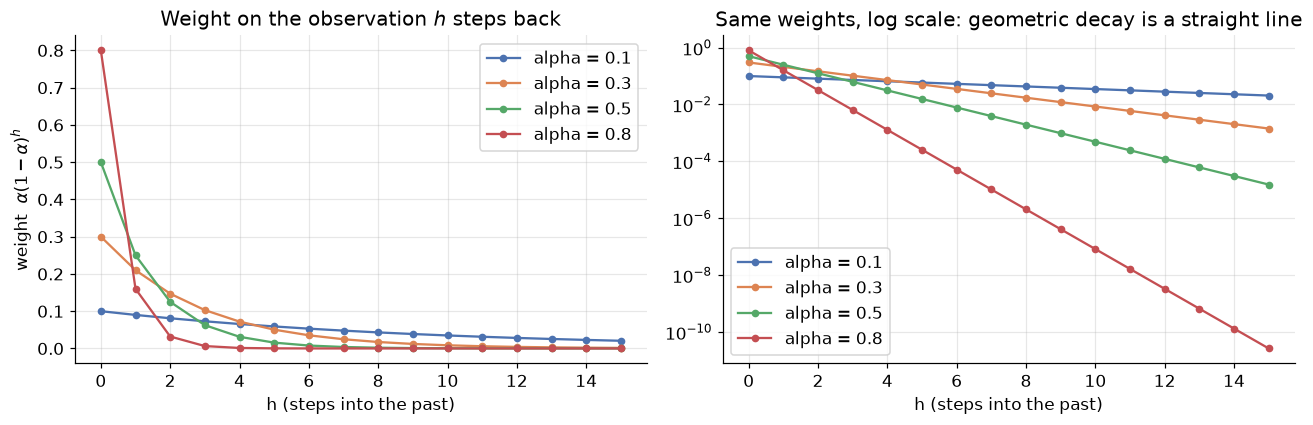

In [2]:
alphas = [0.1, 0.3, 0.5, 0.8]
lags = np.arange(0, 16)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for a in alphas:
    w = a * (1 - a) ** lags
    axes[0].plot(lags, w, marker="o", ms=4, label=f"alpha = {a}")
    axes[1].semilogy(lags, w, marker="o", ms=4, label=f"alpha = {a}")

axes[0].set_title("Weight on the observation $h$ steps back")
axes[0].set_xlabel("h (steps into the past)"); axes[0].set_ylabel(r"weight  $\alpha(1-\alpha)^h$")
axes[1].set_title("Same weights, log scale: geometric decay is a straight line")
axes[1].set_xlabel("h (steps into the past)")
axes[0].legend(); axes[1].legend()
plt.tight_layout()
plt.show()

The left panel is the whole idea in one picture. A **small $\alpha$** gives a slowly decaying, nearly flat
profile: many past observations contribute, so the forecast is smooth and slow to react — it behaves like
the mean. A **large $\alpha$** dumps almost all the weight onto the last one or two observations: the
forecast is jumpy and reacts instantly — it behaves like naive. In the limits, $\alpha \to 1$ *is* the
naive forecast and $\alpha \to 0$ approaches the mean forecast. Exponential smoothing does not replace
those two baselines; it **interpolates between them**, and $\alpha$ is the dial.

The right panel plots the same curves on a log scale, where every one becomes a straight line. That is the
signature of geometric decay, and the slope of each line is $\log(1-\alpha)$. Steeper line, shorter memory.

One thing worth checking, because a weighting scheme that does not sum to 1 is not an average at all.

In [3]:
print("How much of the total weight sits in the most recent k observations?\n")
print(f"{'alpha':>6} {'k=1':>8} {'k=3':>8} {'k=6':>8} {'k=12':>8} {'k=50':>8}   half-life")
for a in alphas:
    w = a * (1 - a) ** np.arange(200)
    cums = [w[:k].sum() for k in (1, 3, 6, 12, 50)]
    half_life = np.log(0.5) / np.log(1 - a)          # lags until the weight halves
    print(f"{a:>6} " + " ".join(f"{c:>8.4f}" for c in cums) + f"   {half_life:>6.1f} periods")

How much of the total weight sits in the most recent k observations?

 alpha      k=1      k=3      k=6     k=12     k=50   half-life
   0.1   0.1000   0.2710   0.4686   0.7176   0.9948      6.6 periods
   0.3   0.3000   0.6570   0.8824   0.9862   1.0000      1.9 periods
   0.5   0.5000   0.8750   0.9844   0.9998   1.0000      1.0 periods
   0.8   0.8000   0.9920   0.9999   1.0000   1.0000      0.4 periods


Read the `k=50` column first: for every $\alpha$ the weights sum to essentially exactly 1. That is not a
coincidence, it is a geometric series — $\sum_{h=0}^{\infty} \alpha(1-\alpha)^h = \alpha \cdot
\frac{1}{1-(1-\alpha)} = 1$ — and it is what licenses us to call this a **weighted average** rather than
just a weighted sum.

Now read across the rows. At $\alpha = 0.1$, the most recent 12 observations carry only about 72% of the
weight; the model is still listening to things that happened years ago. At $\alpha = 0.8$, the last three
observations carry 99.2% and everything beyond is rounding error. The **half-life** column makes this
concrete: it is the number of periods you have to go back before an observation's weight has halved. At
$\alpha = 0.1$ that is about 6.6 periods; at $\alpha = 0.8$ it is about 0.4 — memory measured in
fractions of a month.

> **$\alpha$ is a memory dial.** Small $\alpha$ = long memory, smooth forecasts, slow to adapt. Large
> $\alpha$ = short memory, responsive forecasts, sensitive to noise.

Choosing it by hand would be arbitrary. In Section 2 we let the data choose.

---
## 2. Simple Exponential Smoothing

Writing the forecast as an infinite weighted sum is correct but useless for computation. The standard
presentation — the **component form** — is a pair of equations that generate exactly the same forecasts
while storing only one number:

$$\text{Forecast equation:}\quad \hat{y}_{t+h|t} = \ell_t$$
$$\text{Level equation:}\quad\ \ \ \ell_t = \alpha y_t + (1-\alpha)\,\ell_{t-1}$$

Here $\ell_t$ is the **level**: the model's current best estimate of where the series *is*, stripped of
noise. The level equation is a compromise, and reading it aloud is the fastest route to intuition: *the
new level is a blend of what we just observed ($y_t$) and what we previously believed ($\ell_{t-1}$),
mixed in proportion $\alpha$ to $1-\alpha$.*

The forecast equation says something stark: **the forecast is flat**. $\hat{y}_{t+h|t} = \ell_t$ for every
horizon $h$ — one month ahead, twelve months ahead, a decade ahead, the same number. SES has exactly one
component, a level, and a level does not go anywhere by itself. Hold on to this; it is the limitation that
Sections 3 and 4 exist to remove.

### Where the exponential weights went

The two forms are the same thing. Substitute the level equation into itself repeatedly:

$$\ell_t = \alpha y_t + (1-\alpha)\ell_{t-1} = \alpha y_t + \alpha(1-\alpha) y_{t-1} + (1-\alpha)^2 \ell_{t-2}$$

$$= \alpha y_t + \alpha(1-\alpha)y_{t-1} + \alpha(1-\alpha)^2 y_{t-2} + \cdots + (1-\alpha)^{t}\ell_0$$

There are the Section 1 weights, falling out of a one-line recursion. The last term is the fingerprint of
the starting value $\ell_0$, and its influence decays by $(1-\alpha)^t$ — which is why $\ell_0$ matters a
lot for short series and almost not at all for long ones.

### Implementing it

The recursion is five lines. Let us write it, then check it against statsmodels.

In [4]:
def ses_from_scratch(y, alpha, level0):
    """Simple exponential smoothing. Returns (one-step-ahead forecasts, final level)."""
    level = level0
    fitted = []
    for value in y:
        fitted.append(level)                          # forecast for time t, made at t-1
        level = alpha * value + (1 - alpha) * level    # then absorb the observation
    return np.array(fitted), level

ALPHA = 0.3
l0 = float(train.iloc[0])

mine, final_level = ses_from_scratch(train.values, ALPHA, l0)

theirs = SimpleExpSmoothing(
    train, initialization_method="known", initial_level=l0
).fit(smoothing_level=ALPHA, optimized=False)

print(f"alpha = {ALPHA}, l0 = {l0:.1f}\n")
print(f"{'':<22}{'from scratch':>14}{'statsmodels':>14}")
print(f"{'Final level (= fcst)':<22}{final_level:>14.6f}{theirs.forecast(1).iloc[0]:>14.6f}")
print(f"{'SSE':<22}{np.sum((train.values - mine) ** 2):>14.4f}{theirs.sse:>14.4f}")
print(f"\nLargest disagreement across all {len(mine)} fitted values: "
      f"{np.max(np.abs(mine - theirs.fittedvalues.values)):.2e}")

alpha = 0.3, l0 = 112.0

                        from scratch   statsmodels
Final level (= fcst)      366.056553    366.056553
SSE                      177515.7369   177515.7369

Largest disagreement across all 120 fitted values: 0.00e+00


The two implementations agree to the last bit — the largest disagreement across all 120 fitted values is
`0.00e+00`, an exact match. That is worth doing once for any model you intend to rely on. `SimpleExpSmoothing`
is a heavily optimised, well-tested implementation, but it is running precisely the recursion above, and
now you have seen the whole of it.

Note the arguments we had to pass to get an exact comparison: `initialization_method="known"` with an
explicit `initial_level`, and `.fit(smoothing_level=ALPHA, optimized=False)` to pin $\alpha$ rather than
letting the optimiser choose. Without those, statsmodels estimates both — which is what we want in
practice, and what we do below.

Before moving on, one loop worth closing. Section 1 claimed the recursion *is* the geometrically weighted
average, and the algebra above says so, but claims like that are cheap. Let us evaluate the weighted sum
directly and compare.

In [5]:
alpha, t = ALPHA, len(train)
y_reversed = train.values[::-1]                     # y_T, y_{T-1}, ..., y_1

weighted_sum = np.sum(alpha * (1 - alpha) ** np.arange(t) * y_reversed)
initial_term = (1 - alpha) ** t * l0                # the surviving fingerprint of l0

print(f"Weighted sum of the {t} observations : {weighted_sum:.6f}")
print(f"Contribution of l0, (1-a)^T * l0     : {initial_term:.6f}")
print(f"Total                                : {weighted_sum + initial_term:.6f}")
print(f"Level from the recursion             : {final_level:.6f}")
print(f"\nWeights used sum to {np.sum(alpha * (1 - alpha) ** np.arange(t)):.6f}, "
      f"leaving {(1 - alpha) ** t:.2e} for l0")

Weighted sum of the 120 observations : 366.056553
Contribution of l0, (1-a)^T * l0     : 0.000000
Total                                : 366.056553
Level from the recursion             : 366.056553

Weights used sum to 1.000000, leaving 2.58e-19 for l0


The two routes to the level agree to six decimal places. Note how small the $\ell_0$ contribution has
become: with $\alpha = 0.3$ and 120 observations, $(1-\alpha)^{120}$ is around $10^{-19}$, so the starting
value has been comprehensively forgotten. On a series of ten observations it would still be carrying
non-trivial weight, which is why $\ell_0$ is estimated rather than guessed.

### The effect of $\alpha$

With the recursion in hand we can watch the memory dial directly.

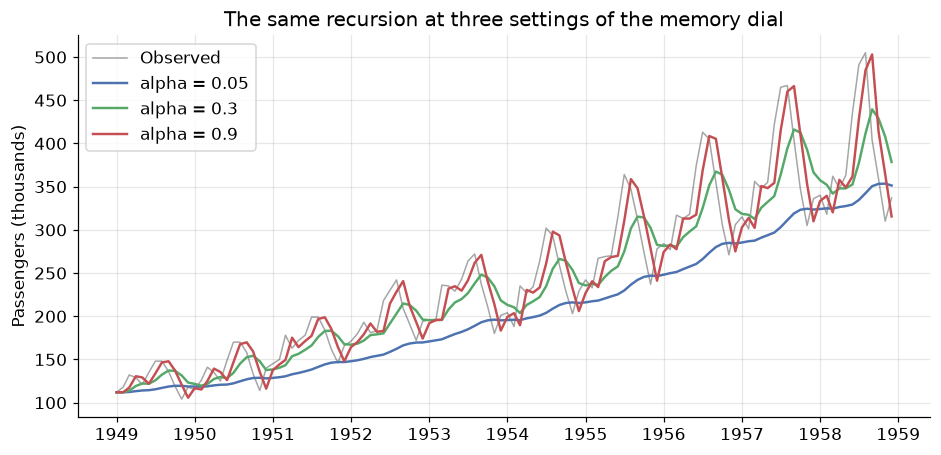

In [6]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(train.index, train.values, color="black", alpha=0.35, lw=1, label="Observed")

for a, color in zip([0.05, 0.3, 0.9], ["C0", "C2", "C3"]):
    smoothed, _ = ses_from_scratch(train.values, a, l0)
    ax.plot(train.index, smoothed, color=color, lw=1.6, label=f"alpha = {a}")

ax.set_title("The same recursion at three settings of the memory dial")
ax.set_ylabel("Passengers (thousands)")
ax.legend()
plt.show()

Three quite different objects, from one equation.

- **$\alpha = 0.05$** (blue) is barely a forecast of this series at all — it is so reluctant to update
  that it lags the data badly, running tens of thousands of passengers below the truth for years at a
  time. Long memory becomes a liability when the thing you are remembering has changed.
- **$\alpha = 0.9$** (red) tracks the series closely enough that the two lines are hard to separate. But
  look at what it is doing: it is essentially reproducing last month's value. It has not smoothed
  anything, it has just delayed the series by one step.
- **$\alpha = 0.3$** (green) is the recognisable compromise, cutting through the seasonal wobble while
  still following the growth.

The red curve exposes the trap. "Closest to the data" is *not* the goal — a model that copies the last
observation fits beautifully in-sample and tells you nothing. But that is exactly what the fitting
criterion is about to reward, so let us look at it carefully.

### Estimating $\alpha$ and $\ell_0$

SES has two unknowns: the smoothing parameter $\alpha$ and the starting level $\ell_0$. Both are chosen
the same way linear regression chooses its coefficients — by minimising the **sum of squared one-step
errors** over the training data:

$$\text{SSE}(\alpha, \ell_0) = \sum_{t=1}^{T}\left(y_t - \hat{y}_{t|t-1}\right)^2 = \sum_{t=1}^{T}(y_t - \ell_{t-1})^2$$

Unlike least squares, there is no closed-form solution — $\ell_{t-1}$ depends on $\alpha$ through the
whole recursion — so it is solved numerically. Let us map the surface by hand first.

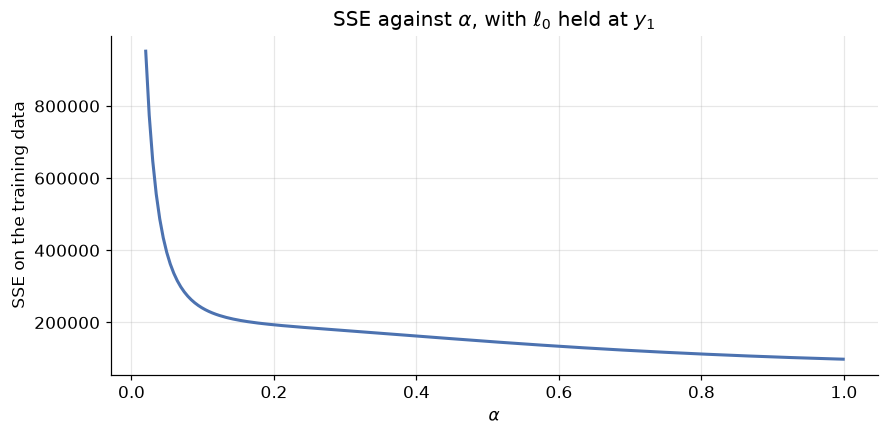

  alpha         SSE
    0.1      239336
    0.3      177516
    0.5      147565
    0.7      122330
    0.9      104537
   0.99       98720

SSE is minimised on this grid at alpha = 0.999


In [7]:
grid = np.linspace(0.02, 0.999, 200)
sses = [np.sum((train.values - ses_from_scratch(train.values, a, l0)[0]) ** 2) for a in grid]

fig, ax = plt.subplots()
ax.plot(grid, sses, color="C0", lw=2)
ax.set_xlabel(r"$\alpha$"); ax.set_ylabel("SSE on the training data")
ax.set_title(r"SSE against $\alpha$, with $\ell_0$ held at $y_1$")
plt.show()

print(f"{'alpha':>7}{'SSE':>12}")
for a in [0.1, 0.3, 0.5, 0.7, 0.9, 0.99]:
    print(f"{a:>7}{np.sum((train.values - ses_from_scratch(train.values, a, l0)[0]) ** 2):>12.0f}")
print(f"\nSSE is minimised on this grid at alpha = {grid[int(np.argmin(sses))]:.3f}")

The curve falls monotonically all the way to the right-hand edge. There is no interior minimum: SSE keeps
improving as $\alpha \to 1$, and the grid search duly returns a value pinned against the boundary.

This is not a bug, and it is the most instructive thing in the section. **On a strongly trending series,
the one-step-ahead SSE criterion always pushes $\alpha$ towards 1.** The reason is that SES has no way to
represent growth, so its only route to a small one-step error is to chase the data — and chasing the data
is exactly what $\alpha = 1$ does. The level equation collapses to $\ell_t = y_t$, and the forecast
becomes $\hat{y}_{t+h|t} = y_T$: **SES with $\alpha = 1$ is precisely the naive method** from module 10.

Now let statsmodels estimate both parameters properly and confirm the diagnosis.

In [8]:
ses_fit = SimpleExpSmoothing(train, initialization_method="estimated").fit()

print(f"Fitted alpha : {ses_fit.params['smoothing_level']:.4f}")
print(f"Fitted l0    : {ses_fit.params['initial_level']:.3f}")
print(f"Training SSE : {ses_fit.sse:.1f}")

ses_fc = ses_fit.forecast(h)
naive_fc = pd.Series(train.iloc[-1], index=idx)
print(f"\nSES forecast for every one of the {h} test months: {ses_fc.iloc[0]:.1f}")
print(f"Last training observation (= the naive forecast):  {train.iloc[-1]:.1f}")
print(f"Max |SES forecast - naive forecast|: {np.max(np.abs(ses_fc - naive_fc)):.2e}")

Fitted alpha : 1.0000
Fitted l0    : 112.001
Training SSE : 98151.0

SES forecast for every one of the 24 test months: 337.0
Last training observation (= the naive forecast):  337.0
Max |SES forecast - naive forecast|: 4.02e-07


The optimiser returns $\alpha = 1.0000$, and the resulting forecast is *identical to the naive forecast*
at every one of the 24 test months — the maximum absolute difference is `4.02e-07`, which is optimiser
tolerance rather than a real gap. The estimated $\ell_0$
of 112.0 is essentially the first observation, and with $\alpha = 1$ it is promptly forgotten anyway.

Do not read this as "SES is useless". Read it as SES telling you, through its parameter estimate, that
**this series contains structure it cannot represent**. A fitted $\alpha$ pinned at 1 is a diagnostic: it
means the series is moving systematically and the model has no component for that movement, so it is
reduced to copying. On a genuinely level series — sales of a mature product, a stable process
measurement — SES returns an interior $\alpha$ and does real work. Here it is the wrong tool, and it says
so.

Let us look at the failure directly, because the shape of it is the whole motivation for Section 3.

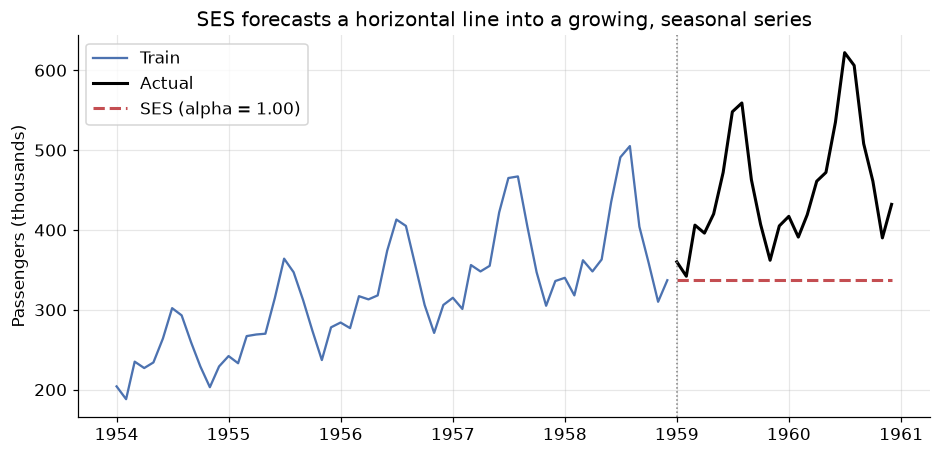

SES on the test set: MAE=115.25  RMSE=137.33  MAPE=23.58  MASE=4.03


In [9]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(train[-60:], color="C0", label="Train")
ax.plot(test, color="black", lw=2, label="Actual")
ax.plot(ses_fc, color="C3", lw=2, ls="--", label=f"SES (alpha = {ses_fit.params['smoothing_level']:.2f})")
ax.axvline(idx[0], color="grey", ls=":", lw=1)
ax.set_title("SES forecasts a horizontal line into a growing, seasonal series")
ax.set_ylabel("Passengers (thousands)")
ax.legend()
plt.show()

ses_scores = evaluate(test, ses_fc, train)
print("SES on the test set: " + "  ".join(f"{k}={v:.2f}" for k, v in ses_scores.items()))

A flat line, drawn straight through the middle of two years of seasonal oscillation around a rising trend.
MAE of 115.25 thousand passengers — considerably *worse* than the seasonal naive baseline's 71.25, and
worse than every module 10 baseline except the mean.

Two distinct failures are visible, and it is worth naming them separately because we fix them separately:

1. **No trend.** The forecast does not rise, so it drifts further below the truth with every passing
   month.
2. **No seasonality.** The forecast is a straight line where the truth has a large, perfectly regular
   annual swing.

One component, one flat line. Add a second component and the forecast can slope. Add a third and it can
oscillate.

---
## 3. Holt's linear trend method

Charles Holt's 1957 extension is exactly what the diagnosis calls for: give the model a **second
component** that tracks not where the series is, but how fast it is moving. Alongside the level $\ell_t$
we now carry a slope $b_t$, smoothed by its own parameter $\beta^*$:

$$\text{Forecast:}\quad \hat{y}_{t+h|t} = \ell_t + h\,b_t$$
$$\text{Level:}\quad\ \ \ \ \ell_t = \alpha y_t + (1-\alpha)(\ell_{t-1} + b_{t-1})$$
$$\text{Trend:}\quad\ \ \ \ b_t = \beta^*(\ell_t - \ell_{t-1}) + (1-\beta^*)\,b_{t-1}$$

Three changes, each worth pausing on.

The **forecast equation** is no longer flat. $\hat{y}_{t+h|t} = \ell_t + h b_t$ is a straight line through
the current level with slope $b_t$ — the forecast now extrapolates, and it grows linearly with the
horizon.

The **level equation** now blends $y_t$ against $\ell_{t-1} + b_{t-1}$ rather than $\ell_{t-1}$. That is
just honesty about what "what we previously believed" means: last period we believed the level was
$\ell_{t-1}$ *and* that it was climbing at $b_{t-1}$, so our prior expectation for this period was the sum
of the two.

The **trend equation** is SES applied to the slope. The "observation" of the slope at time $t$ is
$\ell_t - \ell_{t-1}$, how much the level actually moved; $\beta^*$ controls how much of that we believe
versus how much we stick with our previous slope estimate. Small $\beta^*$ means a slope that changes only
slowly — a stable, long-run growth rate.

That is the pattern for the whole family, and it will repeat once more in Section 4: **one component, one
smoothing parameter, one line in the forecast equation.**

In [10]:
holt_fit = Holt(train, initialization_method="estimated").fit()

print("Holt's linear trend method")
print(f"  alpha (level) : {holt_fit.params['smoothing_level']:.4f}")
print(f"  beta* (trend) : {holt_fit.params['smoothing_trend']:.4f}")
print(f"  l0            : {holt_fit.params['initial_level']:.3f}")
print(f"  b0            : {holt_fit.params['initial_trend']:.4f}   (passengers per month)")
print(f"  Training SSE  : {holt_fit.sse:.1f}   (SES was {ses_fit.sse:.1f})")

holt_fc = holt_fit.forecast(h)
print(f"\nForecast rises from {holt_fc.iloc[0]:.1f} to {holt_fc.iloc[-1]:.1f} over the {h} test months")
print("Holt on the test set: " + "  ".join(f"{k}={v:.2f}" for k, v in evaluate(test, holt_fc, train).items()))

Holt's linear trend method
  alpha (level) : 1.0000
  beta* (trend) : 0.0000
  l0            : 110.109
  b0            : 1.8907   (passengers per month)
  Training SSE  : 97725.6   (SES was 98151.0)

Forecast rises from 338.9 to 382.4 over the 24 test months
Holt on the test set: MAE=91.62  RMSE=115.70  MAPE=18.41  MASE=3.21


The forecast now slopes: it climbs from 338.9 to 382.4 across the two test years, and MAE falls from
115.25 to 91.62 — a real improvement over SES, and now better than the drift baseline's... well. Look
more carefully.

The fitted parameters are $\alpha = 1.0000$ and $\beta^* = 0.0000$, both pinned at their boundaries again,
and the story they tell is precise. $\alpha = 1$ means the level simply copies the last observation, as
before. $\beta^* = 0$ means the slope **never updates at all**: $b_t = b_0$ for every $t$, frozen at its
estimated initial value of about 1.89 passengers per month. So Holt's forecast here is "the last
observation, plus a constant slope times the horizon" — which is the definition of the **drift** method
from module 10. Let us verify that rather than assert it.

In [11]:
drift_fc = pd.Series(
    train.iloc[-1] + np.arange(1, h + 1) * (train.iloc[-1] - train.iloc[0]) / (len(train) - 1),
    index=idx,
)

print(f"Holt's fitted b0                    : {holt_fit.params['initial_trend']:.6f}")
print(f"Drift slope (y_T - y_1) / (T - 1)   : "
      f"{(train.iloc[-1] - train.iloc[0]) / (len(train) - 1):.6f}")
print(f"\nMax |Holt forecast - drift forecast| over the test set: "
      f"{np.max(np.abs(holt_fc - drift_fc)):.2e}")

Holt's fitted b0                    : 1.890749
Drift slope (y_T - y_1) / (T - 1)   : 1.890756

Max |Holt forecast - drift forecast| over the test set: 1.81e-04


The two slopes agree to four decimal places and the forecasts differ by less than $2 \times 10^{-4}$
passengers across the whole test set. **Holt has rediscovered the drift method from scratch**, by
optimisation rather than by stipulation.

> **A reproducibility note worth internalising.** We passed `initialization_method="estimated"`, which
> asks the optimiser to fit $\ell_0$ and $b_0$ jointly with $\alpha$ and $\beta^*$. If you instead write
> the bare `Holt(train).fit()`, statsmodels uses a different default starting rule, lands on
> $\beta^* = 0.0065$ rather than exactly 0, and reports a **better** test MAE of 73.34. Before you prefer
> that: its training SSE is 99385.9 against our 97725.6, so it is the *worse* fit to the data — it simply
> got lucky on these 24 months. This is a small, clean example of a trap that will cost you real money
> one day: **a model that scores better on one test window is not thereby the better model.** Compare fits
> on the objective they were fitted to, and treat a single test window as one noisy sample.

That is a genuinely satisfying result — the drift baseline is not an arbitrary rule of thumb, it is the
degenerate corner of a real model — but it also tells us Holt has not bought us much *here*. It fixed
failure (1) from Section 2, the missing trend. Failure (2), the missing seasonality, is untouched, and on
a series where the seasonal swing is $\pm 25\%$ that is the larger of the two problems.

### Damped trend

Before we add seasonality, one important refinement to the trend itself. Holt's forecast is
$\ell_t + h b_t$: a straight line, extrapolated **indefinitely**. Forecast 100 months out and it will
happily project a level 100 slopes above today's. Empirically that is almost always too optimistic — real
series flatten, saturate, mean-revert, hit capacity limits — and long-horizon linear extrapolation is one
of the most reliable ways to embarrass yourself with a forecast.

Gardner and McKenzie's fix introduces a **damping parameter** $\phi \in (0, 1)$:

$$\hat{y}_{t+h|t} = \ell_t + (\phi + \phi^2 + \cdots + \phi^h)\,b_t$$
$$\ell_t = \alpha y_t + (1-\alpha)(\ell_{t-1} + \phi b_{t-1}), \qquad
b_t = \beta^*(\ell_t - \ell_{t-1}) + (1-\beta^*)\phi\, b_{t-1}$$

Each additional step contributes only $\phi$ times what the previous one did, so the cumulative trend is a
geometric series. As $h \to \infty$ it converges to $\ell_t + \frac{\phi}{1-\phi}b_t$ — a **finite
asymptote**. The forecast still rises, but it flattens out instead of running away. $\phi = 1$ recovers
undamped Holt exactly; in practice $\phi$ is estimated and usually lands between 0.8 and 0.98.

In [12]:
holt_damped = Holt(train, damped_trend=True, initialization_method="estimated").fit()

print("Damped Holt")
print(f"  alpha : {holt_damped.params['smoothing_level']:.4f}")
print(f"  beta* : {holt_damped.params['smoothing_trend']:.4f}")
print(f"  phi   : {holt_damped.params['damping_trend']:.4f}")
print(f"  SSE   : {holt_damped.sse:.1f}   (undamped Holt: {holt_fit.sse:.1f})")

damped_fc = holt_damped.forecast(h)
print("\n            " + "  ".join(f"{k:>8}" for k in ["MAE", "RMSE", "MAPE", "MASE"]))
for name, fc in [("Holt      ", holt_fc), ("Holt damped", damped_fc)]:
    s = evaluate(test, fc, train)
    print(f"{name}  " + "  ".join(f"{v:>8.2f}" for v in s.values()))

Damped Holt
  alpha : 1.0000
  beta* : 0.0000
  phi   : 0.9940
  SSE   : 97696.5   (undamped Holt: 97725.6)

                 MAE      RMSE      MAPE      MASE
Holt           91.62    115.70     18.41      3.21
Holt damped     99.67    122.85     20.17      3.49


$\phi = 0.9940$ — very close to 1, so the damping is gentle, and the training SSE improves only slightly
(97696.5 against 97725.6). On the **test set** damping actually makes things marginally worse: MAE rises
from 91.62 to 99.67.

That is the honest result and it deserves an honest reading rather than a rescue. Over a 24-month horizon
Air Passengers really does keep growing roughly linearly, so holding the trend back costs accuracy.
Damping is insurance, and insurance has a premium. The premium is worth paying when the horizon is long
relative to the data, when the series might plausibly saturate, or when you are forecasting many series
automatically and cannot inspect each one. Over two years of a series that has grown steadily for a
decade, it is not.

The place damping earns its keep is far out. Extend both forecasts to five years and the divergence
becomes obvious.

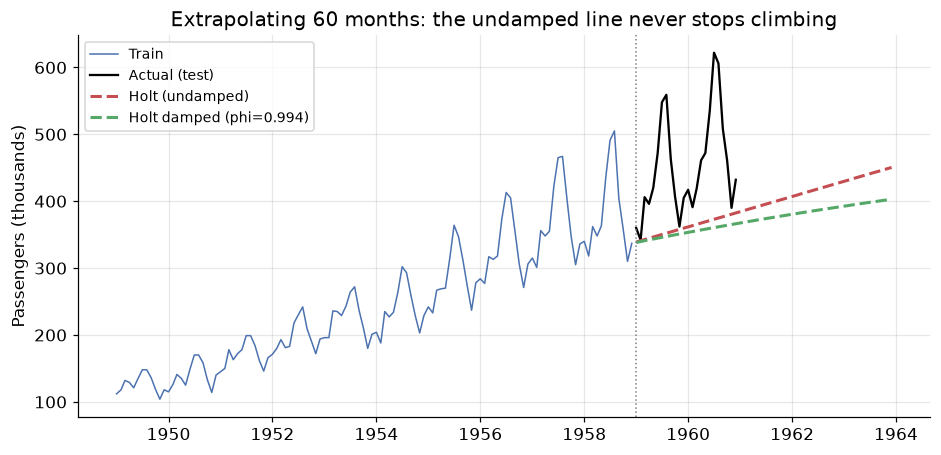

At h = 60:  undamped = 450.4   damped = 402.9
Damped asymptote as h -> infinity: 554.0


In [13]:
LONG = 60
long_holt = holt_fit.forecast(LONG)
long_damped = holt_damped.forecast(LONG)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(train, color="C0", lw=1, label="Train")
ax.plot(test, color="black", lw=1.5, label="Actual (test)")
ax.plot(long_holt, color="C3", lw=2, ls="--", label="Holt (undamped)")
ax.plot(long_damped, color="C2", lw=2, ls="--", label=f"Holt damped (phi={holt_damped.params['damping_trend']:.3f})")
ax.axvline(idx[0], color="grey", ls=":", lw=1)
ax.set_title(f"Extrapolating {LONG} months: the undamped line never stops climbing")
ax.set_ylabel("Passengers (thousands)")
ax.legend(fontsize=9)
plt.show()

print(f"At h = {LONG}:  undamped = {long_holt.iloc[-1]:.1f}   damped = {long_damped.iloc[-1]:.1f}")
phi = holt_damped.params["damping_trend"]
print(f"Damped asymptote as h -> infinity: "
      f"{holt_damped.level.iloc[-1] + phi / (1 - phi) * holt_damped.trend.iloc[-1]:.1f}")

By month 60 the undamped forecast has reached 450.4 while the damped one sits at 402.9 — a gap of nearly
48 thousand passengers opened up purely by the choice of $\phi$, and that gap widens without limit as the
horizon grows. The printed asymptote is where the damped forecast eventually settles; the undamped
forecast has no asymptote at all.

> **The further out you forecast, the more the trend assumption dominates the answer.** At $h=1$ the
> level does the work and $\phi$ barely matters. At $h=60$ almost the entire forecast is the accumulated
> trend, and $\phi$ *is* the forecast.

Damped trend is the default recommendation for automated forecasting for exactly this reason. But neither
version can help with our actual problem, which is the seasonal swing. Time for the third equation.

---
## 4. Holt-Winters seasonal method

Peter Winters added the third component in 1960, completing the method that still carries both names. The
pattern is by now familiar: a new component $s_t$, a new smoothing parameter $\gamma$, a new line in the
forecast equation. For a series with seasonal period $m$, the **additive** form is

$$\hat{y}_{t+h|t} = \ell_t + h b_t + s_{t+h-m(k+1)}$$
$$\ell_t = \alpha(y_t - s_{t-m}) + (1-\alpha)(\ell_{t-1}+b_{t-1})$$
$$b_t = \beta^*(\ell_t - \ell_{t-1}) + (1-\beta^*)b_{t-1}$$
$$s_t = \gamma(y_t - \ell_{t-1} - b_{t-1}) + (1-\gamma)s_{t-m}$$

where $k = \lfloor (h-1)/m \rfloor$ is bookkeeping that simply means *reuse the seasonal index from the
most recent complete cycle*. The seasonal equation is SES again, this time applied to the seasonal
component and — crucially — updating $s_t$ from $s_{t-m}$, the same month last year, rather than from
$s_{t-1}$.

Note what happened to the level equation: it now smooths $y_t - s_{t-m}$, the **deseasonalised**
observation. The level no longer jumps every July. Each component gets to concentrate on its own job,
which is the whole architectural point of the component form.

### Additive or multiplicative?

Module 10 established that Air Passengers is **multiplicative**: the seasonal swing is a roughly constant
*percentage* of the level, not a constant number of passengers, which is why the series fans outwards. The
seasonal factors we extracted there were multipliers around 1.0 — July about 22–23% above trend, November
about 20% below.

Holt-Winters has a matching multiplicative form, in which the seasonal component multiplies instead of
adding:

$$\hat{y}_{t+h|t} = (\ell_t + h b_t)\,s_{t+h-m(k+1)}$$
$$\ell_t = \alpha \frac{y_t}{s_{t-m}} + (1-\alpha)(\ell_{t-1}+b_{t-1}), \qquad
s_t = \gamma \frac{y_t}{\ell_{t-1}+b_{t-1}} + (1-\gamma)s_{t-m}$$

The division does the same job the subtraction did — deseasonalise before updating the level — but
proportionally. In statsmodels the only change is `seasonal="mul"` instead of `seasonal="add"`. Fit both
and let the data adjudicate.

In [14]:
hw_add = ExponentialSmoothing(
    train, trend="add", seasonal="add", seasonal_periods=m, initialization_method="estimated"
).fit()

hw_mul = ExponentialSmoothing(
    train, trend="add", seasonal="mul", seasonal_periods=m, initialization_method="estimated"
).fit()

print(f"{'':<22}{'additive':>12}{'multiplicative':>16}")
for label, key in [("alpha (level)", "smoothing_level"),
                   ("beta* (trend)", "smoothing_trend"),
                   ("gamma (seasonal)", "smoothing_seasonal")]:
    print(f"{label:<22}{hw_add.params[key]:>12.4f}{hw_mul.params[key]:>16.4f}")
print(f"{'Training SSE':<22}{hw_add.sse:>12.1f}{hw_mul.sse:>16.1f}")
print(f"{'AIC':<22}{hw_add.aic:>12.1f}{hw_mul.aic:>16.1f}")

                          additive  multiplicative
alpha (level)               0.2367          0.3642
beta* (trend)               0.0000          0.0000
gamma (seasonal)            0.7633          0.6358
Training SSE               16033.6         10764.2
AIC                          619.4           571.6


The multiplicative form wins decisively on the training data: SSE of 10764.2 against 16033.6, and AIC of
571.6 against 619.4. Both criteria point the same way, and the margin is not subtle — the additive fit
carries about 49% more squared error. **The visual diagnostic from module 10 and the numerical criterion
here agree**, which is the comfortable case. When they disagree, trust the plot and check whether your
seasonal period is right.

The smoothing parameters are also worth reading, because none of them is pinned at a boundary this time
except one. For the multiplicative fit, $\alpha = 0.3642$ is a genuinely interior value — the level is
being smoothed, not merely copied, which is the first time in this notebook that has happened.
$\gamma = 0.6358$ is high: the seasonal profile is being allowed to evolve fairly quickly from year to
year, consistent with the STL finding in module 10 that the seasonal amplitude grows across the decade.

And $\beta^* = 0.0000$ is pinned at zero again — the slope is frozen at its initial estimate. This is
extremely common for Holt-Winters and not a cause for alarm. With a level that updates freely and a
seasonal component absorbing the annual pattern, a constant long-run growth rate is genuinely all the
trend this series needs.

Now the forecast.

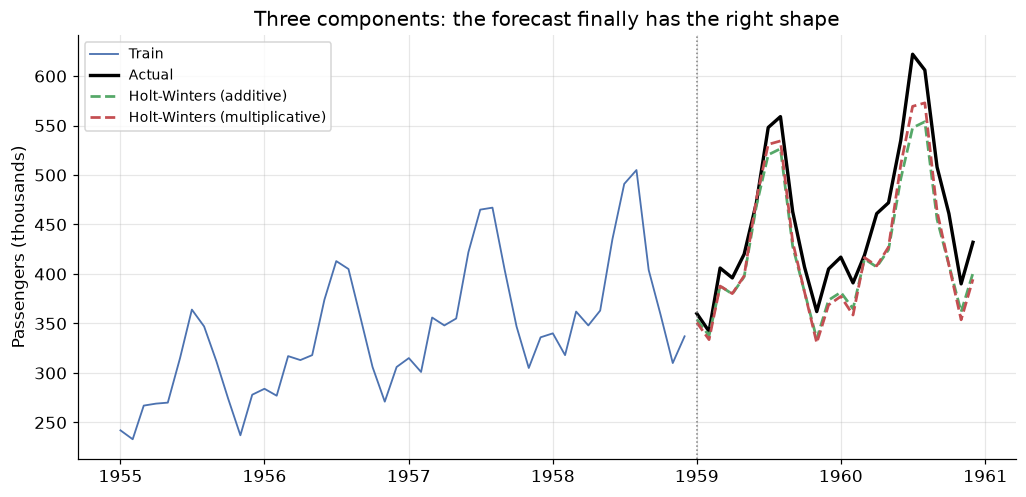

                 MAE      RMSE      MAPE      MASE
HW additive     31.08     35.76      6.64      1.09
HW multipl.     28.98     32.49      6.39      1.01


In [15]:
hw_add_fc = hw_add.forecast(h)
hw_mul_fc = hw_mul.forecast(h)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(train[-48:], color="C0", lw=1.2, label="Train")
ax.plot(test, color="black", lw=2.2, label="Actual")
ax.plot(hw_add_fc, color="C2", lw=1.8, ls="--", label="Holt-Winters (additive)")
ax.plot(hw_mul_fc, color="C3", lw=1.8, ls="--", label="Holt-Winters (multiplicative)")
ax.axvline(idx[0], color="grey", ls=":", lw=1)
ax.set_title("Three components: the forecast finally has the right shape")
ax.set_ylabel("Passengers (thousands)")
ax.legend(fontsize=9)
plt.show()

print("            " + "  ".join(f"{k:>8}" for k in ["MAE", "RMSE", "MAPE", "MASE"]))
for name, fc in [("HW additive", hw_add_fc), ("HW multipl.", hw_mul_fc)]:
    print(f"{name}  " + "  ".join(f"{v:>8.2f}" for v in evaluate(test, fc, train).values()))

After three sections of flat lines and sloped lines, here is a forecast that actually *looks like the
data*: rising, oscillating, peaking in the summers, dipping in the autumns, and doing all of it with
increasing amplitude.

The multiplicative version scores MAE 28.98 against the additive version's 31.08 — a 6.8% improvement,
smaller than the training-SSE gap suggested but in the same direction, and it wins on all four metrics.
Look at the summer peaks in the plot to see why: the additive forecast applies the *same absolute* July
bump it learned from the early 1950s to the much larger series of 1959–60, so it undershoots the peaks.
The multiplicative version applies a percentage and scales with the level.

Both are enormous improvements on everything before them. Recall the target: seasonal naive scored MAE
71.25. Let us confirm the improvement rather than eyeball it, and see the fitted components that produced
it.

Seasonal naive MAE          : 71.25
Holt-Winters (mult) MAE     : 28.98
Reduction in MAE            : 59.3%


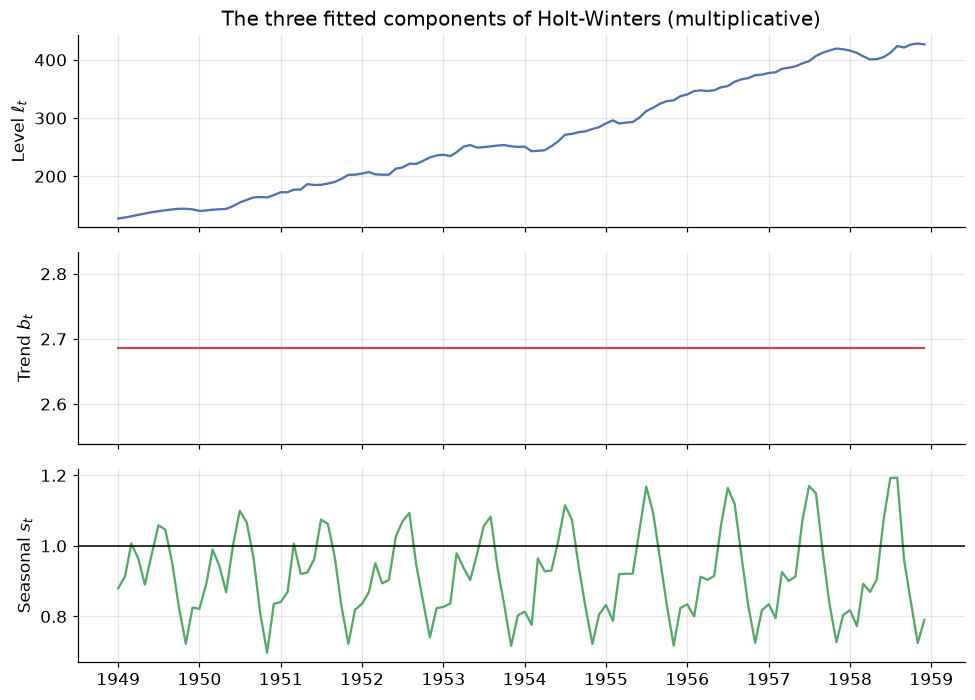

In [16]:
sn_fc = pd.Series(train.iloc[-m:].values[np.arange(h) % m], index=idx)
sn_mae = evaluate(test, sn_fc, train)["MAE"]
hw_mae = evaluate(test, hw_mul_fc, train)["MAE"]

print(f"Seasonal naive MAE          : {sn_mae:.2f}")
print(f"Holt-Winters (mult) MAE     : {hw_mae:.2f}")
print(f"Reduction in MAE            : {100 * (1 - hw_mae / sn_mae):.1f}%")

fig, axes = plt.subplots(3, 1, figsize=(9, 6.5), sharex=True)
axes[0].plot(hw_mul.level, color="C0");    axes[0].set_ylabel("Level $\\ell_t$")
axes[1].plot(hw_mul.trend, color="C3");    axes[1].set_ylabel("Trend $b_t$")
axes[2].plot(hw_mul.season, color="C2");   axes[2].set_ylabel("Seasonal $s_t$")
axes[2].axhline(1.0, color="black", lw=1)
axes[0].set_title("The three fitted components of Holt-Winters (multiplicative)")
plt.tight_layout()
plt.show()

Holt-Winters cuts seasonal naive's MAE by **59.3%** — the module 10 champion beaten by better than half,
which is a large margin by forecasting standards.

The three component panels are the model's internal state, and they are readable in exactly the same way
as module 10's decomposition panels. The **level** is a smooth, deseasonalised climb — this is the series
with its annual pattern surgically removed, and it is what the level equation was always trying to
estimate. The **trend** panel is a flat horizontal line, which is $\beta^* = 0$ made visible: the slope
never moves off $b_0$. The **seasonal** panel oscillates around 1.0, the multiplicative baseline, with the
same summer-peak/autumn-trough profile module 10 recovered by decomposition.

That is the point worth carrying away from this section. `seasonal_decompose` and STL *describe* a series
by splitting it into components; Holt-Winters splits it into components in order to *forecast* it, using
the same vocabulary. A fitted Holt-Winters model is a decomposition that knows how to extrapolate itself.

The seasonal panel is easier to read one cycle at a time, so let us pull out the twelve monthly factors.

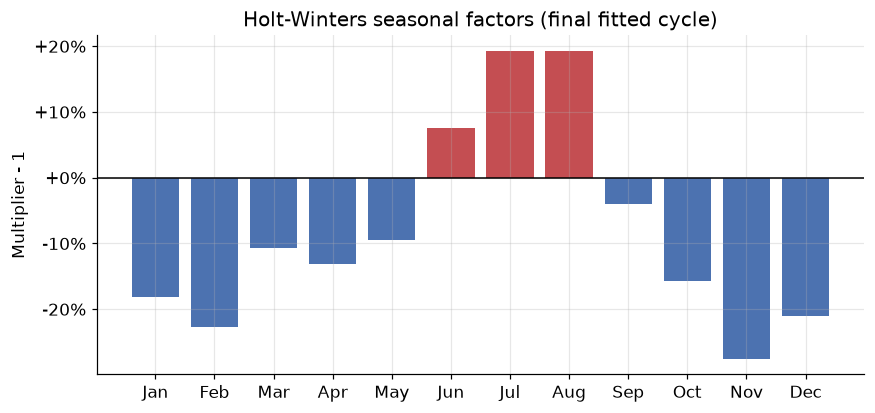

Highest : Aug  (1.193 -> +19.3% vs the level)
Lowest  : Nov  (0.724 -> -27.6% vs the level)


In [17]:
last_cycle = hw_mul.season[-m:]                     # one full cycle of fitted seasonal factors
factors = pd.Series(last_cycle.values, index=[d.strftime("%b") for d in last_cycle.index]).sort_index(key=lambda i: [
    ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"].index(x) for x in i])

fig, ax = plt.subplots()
colors = ["C3" if v > 1 else "C0" for v in factors]
ax.bar(factors.index, factors - 1, color=colors)
ax.axhline(0, color="black", lw=1)
ax.set_title("Holt-Winters seasonal factors (final fitted cycle)")
ax.set_ylabel("Multiplier - 1")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:+.0%}")
plt.show()

print(f"Highest : {factors.idxmax()}  ({factors.max():.3f} -> {factors.max() - 1:+.1%} vs the level)")
print(f"Lowest  : {factors.idxmin()}  ({factors.min():.3f} -> {factors.min() - 1:+.1%} vs the level)")

August runs 19.3% above the level and November 27.6% below — a summer-holiday profile, recovered without
being told anything about calendars, holidays or the airline business. Compare it to module 10's classical
decomposition, which put the peak in July at about +22% and the November trough at about $-20\%$. The
shapes agree; the exact numbers do not, and the reason is $\gamma = 0.6358$. Classical decomposition
averages every January together and reports **one** profile for the whole decade. Holt-Winters with a high
$\gamma$ lets the profile drift, and what we have printed here is the **final** fitted cycle — the 1958
seasonality, not the 1949–58 average. Module 10's STL panel showed exactly this drift; here the forecast
is built from it.

The model has not been told any of this — no calendar, no holiday dummies, no domain knowledge. It has
inferred an interpretable annual profile purely from the recursion in the seasonal equation, and that
interpretability is a large part of why this family remains so widely used.

---
## 5. Comparison and diagnostics

Time to put everything on one table. Same series, same 24-month hold-out, same four metrics, module 10's
four baselines alongside this module's five models. This is the only comparison that means anything:
different methods on **identical** test data.

In [18]:
forecasts = {
    # --- module 10 baselines ---
    "Mean":                 pd.Series(train.mean(), index=idx),
    "Naive":                naive_fc,
    "Seasonal naive":       sn_fc,
    "Drift":                drift_fc,
    # --- this module ---
    "SES":                  ses_fc,
    "Holt":                 holt_fc,
    "Holt (damped)":        damped_fc,
    "Holt-Winters (add)":   hw_add_fc,
    "Holt-Winters (mult)":  hw_mul_fc,
}

scores = pd.DataFrame({name: evaluate(test, fc, train) for name, fc in forecasts.items()}).T
scores = scores.sort_values("MASE")
print(scores.round(2).to_string())

                        MAE    RMSE   MAPE  MASE
Holt-Winters (mult)   28.98   32.49   6.39  1.01
Holt-Winters (add)    31.08   35.76   6.64  1.09
Seasonal naive        71.25   76.99  15.52  2.49
Drift                 91.62  115.70  18.41  3.21
Holt                  91.62  115.70  18.41  3.21
Holt (damped)         99.67  122.85  20.17  3.49
Naive                115.25  137.33  23.58  4.03
SES                  115.25  137.33  23.58  4.03
Mean                 206.34  219.44  44.23  7.22


Read this table from the bottom up; the story is in the ordering.

**The mean forecast is last**, as it was in module 10, and by a wide margin — it is the only method here
that ignores both the trend and the level.

**Naive and SES are tied to the penny** (MAE 115.25 for both), because Section 2 showed they are the same
forecast once $\alpha$ is estimated at 1.

**Drift and Holt are likewise tied** (MAE 91.62), for the reason Section 3 verified: with $\beta^*$
estimated at 0, Holt *is* drift. Damped Holt sits just behind them at 99.67.

**Seasonal naive at MAE 71.25 beats all four of those**, and this is the single most useful line in the
table. Three of the methods below it are more sophisticated models with fitted parameters; the fourth is
"copy last year". On a strongly seasonal series, a method that captures the seasonality with no
parameters at all beats methods that capture the trend beautifully and the seasonality not at all.
**Match the model to the structure that dominates your series.**

**The two Holt-Winters variants take the top two places** — and they are the only two methods in the table
that model all three components. Multiplicative wins, at MAE 28.98 and MASE 1.01, with additive close
behind at 31.08.

That MASE of 1.01 is worth a moment, because module 10 warned that its reference point needs care. The
denominator is seasonal naive's *in-sample, one-season-ahead* MAE of about 28.6. A MASE of 1.01 therefore
says something quite strong: **forecasting up to two years ahead into data the model has never seen is now
about as accurate as seasonal naive was at predicting one season ahead inside its own training data.**
That is the qualitative jump this module was for.

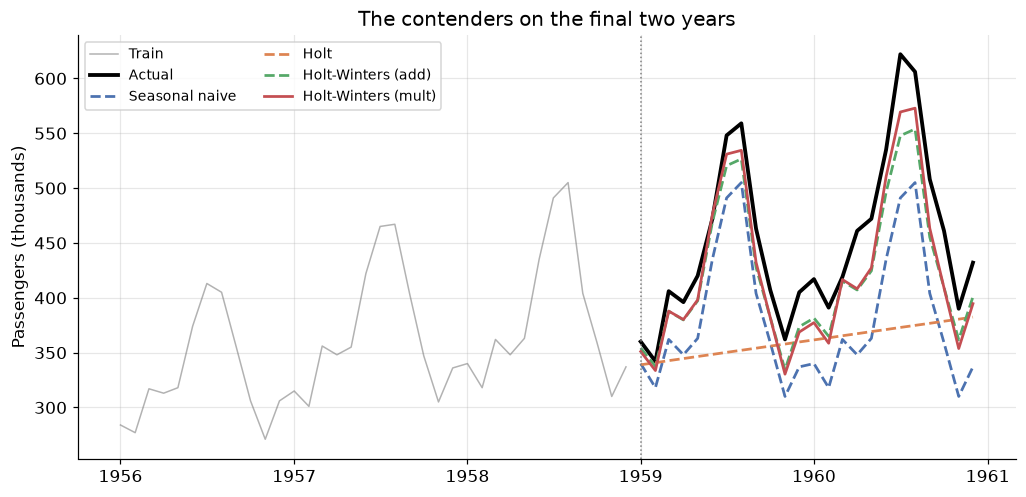

In [19]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(train[-36:], color="grey", lw=1, alpha=0.6, label="Train")
ax.plot(test, color="black", lw=2.5, label="Actual")

for name, style, color in [("Seasonal naive", "--", "C0"),
                           ("Holt",           "--", "C1"),
                           ("Holt-Winters (add)",  "--", "C2"),
                           ("Holt-Winters (mult)", "-",  "C3")]:
    ax.plot(forecasts[name], ls=style, lw=1.8, color=color, label=name)

ax.axvline(idx[0], color="grey", ls=":", lw=1)
ax.set_title("The contenders on the final two years")
ax.set_ylabel("Passengers (thousands)")
ax.legend(fontsize=9, ncol=2)
plt.show()

The plot makes the table's ordering visible. Holt (orange) has the right *level* and the wrong *shape* —
a straight line through oscillating data. Seasonal naive (blue) has the right *shape* and the wrong
*level* — the correct profile, sitting stubbornly below the truth at every single month, because it is
replaying a smaller year.
Holt-Winters combines the two, and the multiplicative version (red) hugs the black line closely enough
that you have to look at the peaks to separate them.

Notice specifically where seasonal naive's blue line sits relative to the black one: **below it,
everywhere** — all 24 of its residuals are positive. That is module 10's systematic under-forecast, drawn rather than tabulated. So: has
Holt-Winters fixed it? A score cannot answer that. Residuals can.

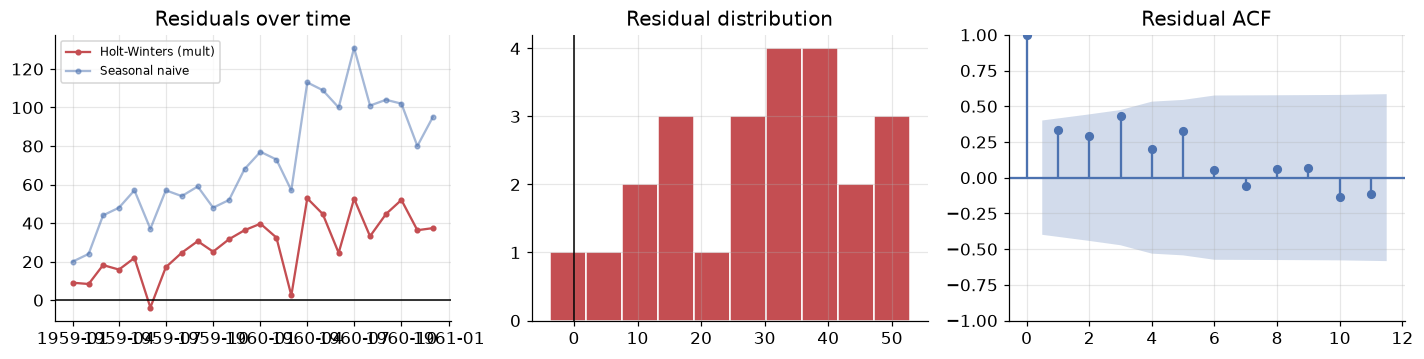

                        mean resid       std   % positive
Seasonal naive              +71.25     29.81       100.0%
Holt-Winters (mult)         +28.66     15.63        95.8%

95% ACF band for 24 residuals: +/- 0.400
Residual ACF, lags 1-6: +0.335  +0.295  +0.429  +0.203  +0.328  +0.056
Lags outside the band:  [3]


In [20]:
best = forecasts["Holt-Winters (mult)"]
resid = test - best
resid_sn = test - forecasts["Seasonal naive"]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
axes[0].plot(resid, color="C3", marker="o", ms=3, label="Holt-Winters (mult)")
axes[0].plot(resid_sn, color="C0", marker="o", ms=3, alpha=0.5, label="Seasonal naive")
axes[0].axhline(0, color="black", lw=1)
axes[0].set_title("Residuals over time"); axes[0].legend(fontsize=8)
axes[1].hist(resid, bins=10, color="C3", edgecolor="white")
axes[1].axvline(0, color="black", lw=1)
axes[1].set_title("Residual distribution")
plot_acf(resid, lags=11, ax=axes[2], title="Residual ACF")
plt.tight_layout()
plt.show()

print(f"{'':<22}{'mean resid':>12}{'std':>10}{'% positive':>13}")
for name, r in [("Seasonal naive", resid_sn), ("Holt-Winters (mult)", resid)]:
    print(f"{name:<22}{r.mean():>+12.2f}{r.std():>10.2f}{100 * (r > 0).mean():>12.1f}%")
band = 1.96 / np.sqrt(len(resid))
print(f"\n95% ACF band for {len(resid)} residuals: +/- {band:.3f}")
r_acf = sm_acf(resid, nlags=6)
print("Residual ACF, lags 1-6: " + "  ".join(f"{v:+.3f}" for v in r_acf[1:]))
print(f"Lags outside the band:  {[k for k in range(1, 7) if abs(r_acf[k]) > band]}")

Now we can answer the question honestly, and the honest answer is **mostly, but not entirely**.

The mean residual falls from $+71.25$ to $+28.66$ — a 60% reduction in bias, and the spread has collapsed
too, from a standard deviation of 29.81 to 15.63. The left panel shows it plainly: the blue seasonal-naive
residuals wander far above zero and swing wildly; the red Holt-Winters residuals sit in a tight band much
closer to it.

But 95.8% of the Holt-Winters residuals are still positive, and a mean residual of $+28.66$ against a
standard deviation of 15.63 is not a small bias. **The model still under-forecasts, just far less.** The
histogram confirms it — the distribution is shifted bodily to the right of zero rather than centred on it.
The residual ACF shows the same thing from another angle: the lag-3 spike at 0.429 pokes just outside the
$\pm 0.400$ band, and with only 24 residuals that band is wide, so we should not over-interpret a single
spike. The persistent positive mean is the real finding.

Why does it persist? The same reason as before, one level deeper. Air Passengers grows roughly
*exponentially*, and Holt's trend component is **linear**. Over 24 months a straight line fitted to
exponential growth will fall progressively behind. The fix is the one module 10 recommended for exactly
this shape of problem: model $\log y_t$, where exponential growth becomes linear growth, then exponentiate
the forecast back. That is Exercise 3.

This is the residual-diagnostics loop doing its job for the second time in two modules. Module 10's
residuals said "you are missing a trend" and pointed us at Holt-Winters. Holt-Winters' residuals say "your
trend is the wrong *functional form*" and point us at logs. The score tells you which model is best; the
residuals tell you what to build next.

### The ETS taxonomy

One piece of vocabulary before the exercises, because you will meet it immediately in any forecasting
package. Everything in this module belongs to a single family, usually labelled **ETS** for
**Error, Trend, Seasonal**. Each model is named by a three-letter code giving the form of each component:

| Component | Options |
|---|---|
| **E**rror | **A**dditive, **M**ultiplicative |
| **T**rend | **N**one, **A**dditive, **A**dditive **d**amped |
| **S**easonal | **N**one, **A**dditive, **M**ultiplicative |

So SES is **ETS(A,N,N)**, Holt is **ETS(A,A,N)**, damped Holt is **ETS(A,A$_d$,N)**, additive
Holt-Winters is **ETS(A,A,A)** and our winner is **ETS(A,A,M)**. Thirty combinations exist; a handful are
numerically unstable and the rest are all fittable. This is exactly what R's celebrated `ets()` function
and statsmodels' `statsmodels.tsa.exponential_smoothing.ets.ETSModel` do automatically: fit the sensible
combinations and pick by **AIC**, the same criterion we used to choose multiplicative over additive above.

The framing also buys something the smoothing recursions alone do not. ETS attaches a full **statistical
model** — with an explicit error term — to each set of equations, which is what makes **prediction
intervals**, likelihoods and information criteria available. The point forecasts are identical; the
inference is not.

Worth knowing where this family sits: ETS models describe a series through **components you can name and
plot**. Module 12's ARIMA family describes it through **autocorrelations** instead. They overlap without
nesting — some ETS models have ARIMA equivalents, others do not — and on a given dataset either may win.
Two different languages for the same problem, and it is genuinely useful to be fluent in both.

---
## 6. Your turn

Add cells below each exercise. Exercises 3 and 5 are the ones that will change how you forecast.

**Exercise 1 — Find a series SES is actually good at.**
SES failed here because Air Passengers trends. Construct a series it should handle well: 200 observations
of a constant level 50 plus $N(0, 5)$ noise, using `rng`. Fit `SimpleExpSmoothing` with
`initialization_method="estimated"` and report the fitted $\alpha$. Then repeat with a series whose level
*shifts* from 50 to 70 at observation 100. How does the fitted $\alpha$ change, and why does a series with
a structural break want a shorter memory?

**Exercise 2 — Map the SSE surface properly.**
Section 2 varied $\alpha$ with $\ell_0$ held fixed at $y_1$. Using `ses_from_scratch`, compute the
training SSE over a 2-D grid of $\alpha \in [0.05, 0.95]$ and $\ell_0 \in [80, 160]$ and draw it with
`plt.contourf`. Is the surface well-behaved? Which of the two parameters does the SSE care about more, and
how does that relate to the $(1-\alpha)^t$ decay of $\ell_0$'s influence?

**Exercise 3 — Fix the remaining bias with logs.**
Section 5 diagnosed the residual $+28.66$ bias as linear trend fitted to exponential growth. Fit
`ExponentialSmoothing(np.log(train), trend="add", seasonal="add", seasonal_periods=12,
initialization_method="estimated")`, forecast 24 months, and exponentiate with `np.exp`. Score it with
`evaluate()` and compute the mean residual. Does it beat ETS(A,A,M), and is the bias closer to zero?
(Additive seasonality on the log scale is the multiplicative model in disguise — explain why.)

**Exercise 4 — Does damping pay off at longer horizons?**
Section 3 found damping hurt over 24 months. Rerun the whole comparison with `TEST_MONTHS = 12` and again
with `TEST_MONTHS = 36`, refitting every model on the shortened training set each time. Plot the MAE gap
between `Holt` and `Holt (damped)` against horizon. At what horizon, if any, does damping start to win —
and does the ranking of the top two methods change?

**Exercise 5 — Rolling-origin validation of the winner.**
The table rests on *one* split from *one* origin. Write a loop that, for origins from month 96 to month
131, fits Holt-Winters (mult) and seasonal naive on `passengers[:origin]` and forecasts 12 months ahead.
Report mean ± std of MASE across origins for each. Does Holt-Winters win at every origin, and what does
the spread tell you about how much confidence the single-split table deserves?

---
## 7. If you remember nothing else

1. **Exponential smoothing is a weighted average that forgets geometrically.** The weight on the
   observation $h$ steps back is $\alpha(1-\alpha)^h$, and those weights sum to 1. The naive forecast
   ($\alpha \to 1$) and the mean forecast ($\alpha \to 0$) are its two limiting cases; everything useful
   lives in between. $\alpha$ is a memory dial, not a fudge factor.

2. **One component, one smoothing parameter, one line in the forecast equation.** SES has a level and
   forecasts a flat line. Holt adds a slope $b_t$ with parameter $\beta^*$ and forecasts a sloped line.
   Holt-Winters adds a seasonal component $s_t$ with parameter $\gamma$ and forecasts an oscillating
   line. Understand the pattern and you can write down any member of the family from its name.

3. **Parameters are fitted by minimising one-step SSE, and the fitted values are diagnostics.** An
   $\alpha$ pinned at 1 means the series contains structure the model cannot represent, so it has been
   reduced to copying the last observation. Here that made SES *identical* to naive and Holt *identical*
   to drift — the module 10 baselines turned out to be degenerate corners of real models.

4. **Match the model to the structure that dominates.** Seasonal naive (MAE 71.25) beat SES, Holt and
   damped Holt on this series, because on strongly seasonal data getting the seasonality right with zero
   parameters beats getting the trend right with three. Only the methods with all three components —
   both Holt-Winters variants — beat it.

5. **Multiplicative when the swings scale with the level.** Air Passengers fans out, so ETS(A,A,M) beat
   ETS(A,A,A) on training SSE (10764.2 vs 16033.6), on AIC (571.6 vs 619.4) and on test MAE (28.98 vs 31.08).
   Damp the trend ($\phi < 1$) when you forecast far out: over 60 months undamped reached 450.4 against
   damped's 402.9, and only the damped forecast has a finite asymptote.

6. **Always read the residuals, then build what they tell you to.** Module 10's residuals showed a
   systematic $+71.25$ under-forecast and pointed at Holt-Winters; Holt-Winters cut it by 59.3% on MAE and
   reduced the bias to $+28.66$ — but 95.8% of residuals are still positive, because a linear trend cannot
   track exponential growth. That residual points at the log transform. The score picks the winner; the
   residuals write the next module.

---
## 8. Further reading and glossary

### Further reading

- Hyndman & Athanasopoulos, [*Forecasting: Principles and Practice*, Chapter 8 — Exponential
  smoothing](https://otexts.com/fpp3/expsmooth.html) — free online, and the definitive treatment of
  everything in this module. Sections 8.1–8.3 are SES, Holt and Holt-Winters in that order; 8.4 gives the
  full ETS taxonomy and 8.5–8.7 add the statistical model and prediction intervals.
- [statsmodels: Exponential smoothing](https://www.statsmodels.org/stable/examples/notebooks/generated/exponential_smoothing.html)
  — the official worked notebook for `SimpleExpSmoothing`, `Holt` and `ExponentialSmoothing`, including
  the Box-Cox and initialisation options we did not use.
- [statsmodels `ETSModel` documentation](https://www.statsmodels.org/stable/generated/statsmodels.tsa.exponential_smoothing.ets.ETSModel.html)
  — the state-space version of this family, which gives likelihoods, AIC and prediction intervals.
- Gardner, [Exponential smoothing: The state of the art — Part II](https://www.sciencedirect.com/science/article/abs/pii/S0169207006000392)
  (2006) — a survey of the first fifty years of the method, and the standard citation for damped trend.
- Hyndman et al., *Forecasting with Exponential Smoothing: The State Space Approach* (2008) — the book
  that unified the whole family under ETS.

### Glossary

| Term | Meaning |
|---|---|
| **Exponential smoothing** | Forecasting by a weighted average with geometrically decaying weights |
| **Smoothing parameter ($\alpha$)** | Weight on the newest observation in the level equation; the memory dial |
| **Level ($\ell_t$)** | The model's current estimate of where the series is, net of season and noise |
| **Trend / slope ($b_t$)** | The model's current estimate of how fast the level is moving per period |
| **Seasonal component ($s_t$)** | The repeating within-cycle deviation, additive or multiplicative |
| **$\beta^*$, $\gamma$** | Smoothing parameters for the trend and seasonal components |
| **Component form** | Writing a model as a forecast equation plus one equation per component |
| **SES** | Simple Exponential Smoothing: level only, flat forecast; ETS(A,N,N) |
| **Holt's linear trend** | SES plus a slope equation; forecast is a straight line; ETS(A,A,N) |
| **Damped trend ($\phi$)** | Shrinks each successive step of the trend by $\phi$, giving a finite asymptote |
| **Holt-Winters** | Holt plus a seasonal equation; ETS(A,A,A) or ETS(A,A,M) |
| **SSE criterion** | Sum of squared one-step-ahead errors, minimised numerically to fit the parameters |
| **ETS** | Error-Trend-Seasonal: the taxonomy naming each model by its three components |
| **AIC** | Information criterion trading fit against parameter count; used to choose within ETS |
| **Prediction interval** | Range in which a future observation should fall; needs the ETS statistical model |
| **Systematic bias** | A mean residual far from zero: the model is wrong in a consistent direction |